Exploratory Data Analysis

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv("clean_books.csv")

In [4]:
df.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    object 
 1   author  350 non-null    object 
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 13.8+ KB


In [6]:
df.describe()

,rating,year
count,350.000000,350.000000
mean,4.608571,2013.508571
std,0.226941,3.284711
min,3.300000,2009.000000
25%,4.500000,2010.000000
50%,4.600000,2013.000000
75%,4.800000,2016.000000
max,4.900000,2019.000000


In [7]:
df.isna()

,name,author,rating,year,genre
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
345,False,False,False,False,False
346,False,False,False,False,False
347,False,False,False,False,False
348,False,False,False,False,False


In [8]:
df.isna().sum()

name      0
author    0
rating    0
year      0
genre     0
dtype: int64

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
345    False
346    False
347    False
348    False
349    False
Length: 350, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["genre"].value_counts()

genre
Non Fiction    179
Fiction        131
Childrens       40
Name: count, dtype: int64

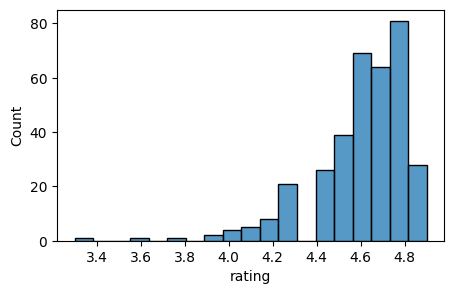

In [12]:
plt.figure(figsize=(5,3))
sns.histplot(df,x="rating")
plt.show()

In [13]:
df[df["genre"].isin(["Fiction","Non Fiction"])].head()   #show data of fictopn and non fiction

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,2011,Fiction


In [14]:
df[~df["genre"].isin(["Fiction","Non Fiction"])].head()

,name,author,rating,year,genre
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens
26,Baby Touch and Feel: Animals,DK,4.6,2015,Childrens
36,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,2017,Childrens
37,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,4.8,2011,Childrens
53,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,2015,Childrens


In [15]:
df.dtypes

name       object
author     object
rating    float64
year        int64
genre      object
dtype: object

In [16]:
df.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


In [17]:
df["year"]=df.year.astype("int")
df["author"]=df.author.astype("string")

In [18]:
df.dtypes

name              object
author    string[python]
rating           float64
year               int64
genre             object
dtype: object

In [19]:
df.select_dtypes('number').head()

,rating,year
0,4.7,2016
1,4.6,2011
2,4.7,2018
3,4.7,2017
4,4.8,2019


In [20]:
df.select_dtypes('number').mean()

rating       4.608571
year      2013.508571
dtype: float64

In [21]:
df.select_dtypes("string").head()

,author
0,JJ Smith
1,Stephen King
2,Jordan B. Peterson
3,George Orwell
4,National Geographic Kids


In [22]:
df.select_dtypes("string").mode()   

,author
0,Jeff Kinney


In [23]:
df.select_dtypes("number").median()

rating       4.6
year      2013.0
dtype: float64

In [24]:
df.select_dtypes("number").agg(["mean","median","min"])

,rating,year
mean,4.608571,2013.508571
median,4.600000,2013.000000
min,3.300000,2009.000000


In [25]:
print(df["year"].min())

2009


In [26]:
print(df["year"].max())

2019


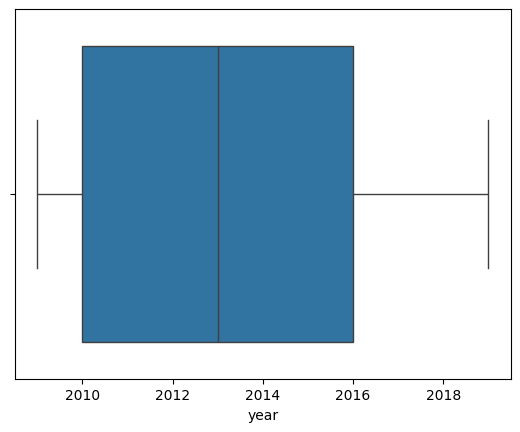

In [27]:
sns.boxplot(df,x="year")
plt.show()

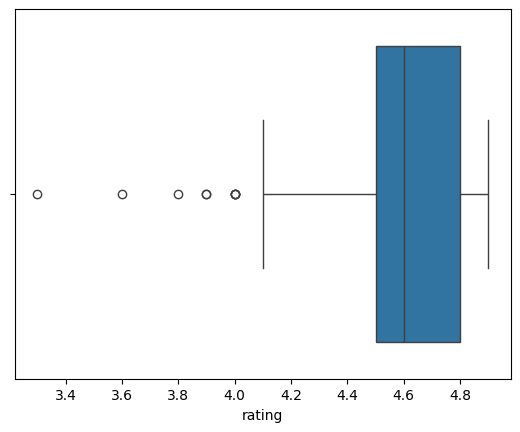

In [28]:
sns.boxplot(df,x="rating")
plt.show()

In [29]:
df[df["genre"]=="Childrens"].mean(numeric_only=True)

rating       4.780
year      2015.075
dtype: float64

In [30]:
df[df["genre"]=="Fiction"].mean(numeric_only=True)

rating       4.570229
year      2013.022901
dtype: float64

In [31]:
df.groupby("genre").mean(numeric_only=True)

,rating,year
genre,,
Childrens,4.780000,2015.075000
Fiction,4.570229,2013.022901
Non Fiction,4.598324,2013.513966


In [32]:
df.groupby("year").mean(numeric_only=True)

,rating
year,
2009,4.584000
2010,4.567500
2011,4.532258
2012,4.482143
2013,4.587879
2014,4.648148
2015,4.623333
2016,4.692593
2017,4.655556


In [33]:
df.groupby("author").mean(numeric_only=True)

,rating,year
author,,
Abraham Verghese,4.60,2010.0
Adam Gasiewski,4.40,2017.0
Adam Mansbach,4.80,2011.0
Adir Levy,4.80,2019.0
Admiral William H. McRaven,4.70,2017.0
...,...,...
Walter Isaacson,4.55,2014.0
William Davis,4.40,2012.0
William P. Young,4.60,2009.0


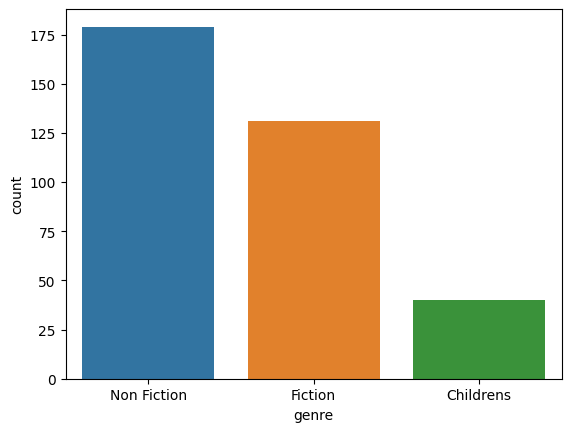

In [34]:
sns.countplot(df,x="genre",hue="genre")
plt.show()

In [35]:
df["genre"].value_counts()

genre
Non Fiction    179
Fiction        131
Childrens       40
Name: count, dtype: int64

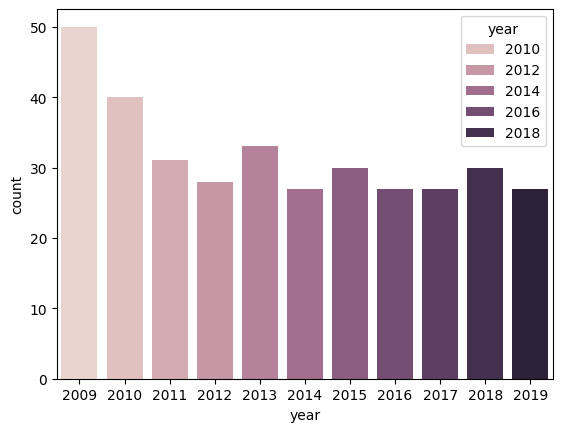

In [36]:
sns.countplot(df,x="year",hue="year")
plt.show()

<Axes: xlabel='year', ylabel='rating'>

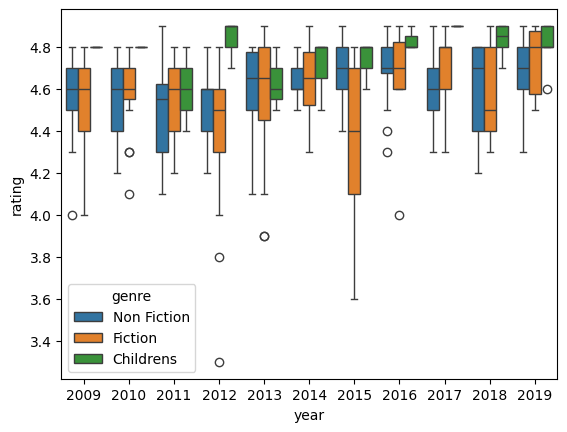

In [37]:
sns.boxplot(df,y="rating",x="year",hue="genre")